# Pertemuan 05 — Hands-on 04: Dari AlexNet ke ResNet — Kedalaman, Blok 3×3, dan Residual
**Mata Kuliah:** Deep Learning (IF25-40401) — Program Studi Teknik Informatika, Institut Teknologi Sumatera (ITERA)
**Materi:** Menelusuri Dimensi & Parameter AlexNet, Tumpukan $3\times3$ VGG, Konvolusi $1\times1$ GoogLeNet, BatchNorm, Eksperimen *Degradation Problem*, Basic & Bottleneck Block ResNet
**Alokasi Waktu:** ~50 Menit (Tatap Muka Kelas TM 3×50′)
**Slide Terkait:** Pertemuan 5, Bagian 01–02 (Slide 6–26)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/informatika-itera/deep-learning-IF25-40401/blob/main/materials/notebooks/04-alexnet-vgg-resnet.ipynb)

---

### Capaian Pembelajaran (Sub-CPMK)
1. **Sub-CPMK 1:** Menjelaskan evolusi CNN dari AlexNet menuju VGG dengan menelusuri dimensi tensor dan distribusi parameter secara empiris.
2. **Sub-CPMK 2:** Membuktikan efisiensi tumpukan filter $3\times3$ (bobot lebih sedikit, *receptive field* sama) dan reduksi kanal dengan konvolusi $1\times1$.
3. **Sub-CPMK 3:** Mereproduksi *degradation problem* pada jaringan *plain* yang dalam dan menunjukkan bagaimana *residual connection* mengatasinya.

---

### Konfigurasi Mode Eksekusi
Saklar `MODE_CEPAT = True` membuat eksperimen pelatihan (Bagian 8) selesai dalam **±2 menit di GPU/MPS** atau **±6–10 menit di CPU**. Ubah menjadi `False` untuk pelatihan penuh 50.000 citra.

> **Catatan angka:** seluruh jumlah parameter dan komputasi dihitung langsung dari model PyTorch, sehingga dapat dicocokkan dengan tabel pada slide.

In [1]:
# Saklar Kecepatan Eksekusi untuk Live-Coding di Kelas
MODE_CEPAT = True  # True: 10.000 citra latih, 5 epoch | False: 50.000 citra latih, 15 epoch

try:
    import torchinfo  # noqa: F401
except ImportError:
    %pip install torchinfo -q

import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch.utils.flop_counter import FlopCounterMode
import torchvision
from torchvision import datasets, transforms, models
from torchinfo import summary

# Reproduktibilitas
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

# Palet warna yang sama dengan slide
TEAL, BLUE, ORANGE, INK, MUTE = '#0A7281', '#1151FF', '#DE8F05', '#111111', '#707072'

print("=" * 65)
print(f"PyTorch / Torchvision : {torch.__version__} / {torchvision.__version__}")
print(f"Perangkat Komputasi   : {device}")
print(f"Status MODE_CEPAT     : {MODE_CEPAT}")
print("=" * 65)

PyTorch / Torchvision : 2.14.0 / 0.29.0
Perangkat Komputasi   : mps
Status MODE_CEPAT     : True


## 1. Alat Bantu: Menghitung Parameter dan Komputasi

Sepanjang notebook kita membutuhkan dua ukuran:
- **Parameter**: jumlah bobot yang dilatih, cukup `sum(p.numel() for p in model.parameters())`.
- **Komputasi**: jumlah operasi *multiply-accumulate* (**MAC**, atau *mult-adds*) untuk satu citra.

Untuk satu layer, rumus MAC-nya:
$$\text{MAC}_{\text{Conv2d}} = \underbrace{C_{out}\cdot H_{out}\cdot W_{out}}_{\text{jumlah nilai output}} \cdot \underbrace{\tfrac{C_{in}}{g}\cdot K\cdot K}_{\text{kali-tambah per output}}, \qquad \text{MAC}_{\text{Linear}} = d_{in}\cdot d_{out}$$

> **Hati-hati istilah:** `torch.utils.flop_counter.FlopCounterMode` menghitung **FLOP = 2 × MAC** (satu kali + satu tambah). Kolom "GFLOPS" pada dokumentasi `torchvision.models` (dan tabel slide 39) sebenarnya adalah **GMAC**. Jadi hasil `FlopCounterMode` harus **dibagi 2** agar cocok dengan tabel.

In [2]:
def hitung_param(model):
    """Jumlah seluruh parameter (bobot + bias) sebuah model."""
    return sum(p.numel() for p in model.parameters())


def hitung_mac(model, input_size=(1, 3, 224, 224)):
    """Total MAC satu forward pass. FlopCounterMode menghitung FLOP = 2 x MAC."""
    model.eval()
    x = torch.randn(*input_size)
    with FlopCounterMode(display=False) as fc, torch.no_grad():
        model(x)
    return fc.get_total_flops() / 2


def rincian_per_layer(model, input_size=(1, 3, 224, 224)):
    """Mencatat (nama, tipe, shape output, parameter, MAC) tiap Conv2d / Linear / Pool via forward hook."""
    catatan, hooks = [], []

    def buat_hook(nama):
        def hook(modul, inp, out):
            n_param = sum(p.numel() for p in modul.parameters())
            if isinstance(modul, nn.Conv2d):
                k = modul.kernel_size[0] * modul.kernel_size[1]
                mac = (out.numel() // out.shape[0]) * (modul.in_channels // modul.groups) * k
            elif isinstance(modul, nn.Linear):
                mac = modul.in_features * modul.out_features
            else:
                mac = 0
            catatan.append((nama, type(modul).__name__, tuple(out.shape[1:]), n_param, mac))
        return hook

    for nama, modul in model.named_modules():
        if isinstance(modul, (nn.Conv2d, nn.Linear, nn.MaxPool2d, nn.AdaptiveAvgPool2d)):
            hooks.append(modul.register_forward_hook(buat_hook(nama)))
    model.eval()
    with torch.no_grad():
        model(torch.randn(*input_size))
    for h in hooks:
        h.remove()
    return catatan


# Uji cepat: ResNet-50 harus ~25,6 juta parameter dan ~4,09 GMAC (lihat slide 39)
r50 = models.resnet50(weights=None)
print(f"ResNet-50 : {hitung_param(r50)/1e6:.2f} juta parameter, {hitung_mac(r50)/1e9:.3f} GMAC")
meta = models.ResNet50_Weights.IMAGENET1K_V1.meta
print(f"Metadata torchvision: {meta['_ops']} 'GFLOPS', top-1 {meta['_metrics']['ImageNet-1K']['acc@1']}%")

ResNet-50 : 25.56 juta parameter, 4.089 GMAC
Metadata torchvision: 4.089 'GFLOPS', top-1 76.13%


## 2. AlexNet: Menelusuri Dimensi Layer demi Layer (Slide 8)

Rumus ukuran output dari Pertemuan 4:
$$W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1$$

Makalah asli AlexNet memakai input $227\times227$, 96 filter $11\times11$, stride 4, tanpa padding. Implementasi `torchvision` memakai varian *"one weird trick"* (Krizhevsky, 2014): input $224\times224$, **64** filter, padding 2. Keduanya menghasilkan *feature map* $55\times55$.

In [3]:
def w_out(w_in, k, s=1, p=0):
    return (w_in - k + 2 * p) // s + 1

print("Makalah asli (227, K=11, S=4, P=0) :", w_out(227, 11, 4, 0))
print("torchvision  (224, K=11, S=4, P=2) :", w_out(224, 11, 4, 2))
print("MaxPool 3x3 stride 2 setelahnya     :", w_out(55, 3, 2, 0))

alexnet = models.alexnet(weights=None)
print(alexnet)

Makalah asli (227, K=11, S=4, P=0) : 55
torchvision  (224, K=11, S=4, P=2) : 55
MaxPool 3x3 stride 2 setelahnya     : 27
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifi

In [4]:
print(f"{'Layer':<14}{'Tipe':<19}{'Shape Output':<18}{'Parameter':>12}{'MAC':>16}")
print("-" * 79)
for nama, tipe, shape, n_param, mac in rincian_per_layer(alexnet):
    print(f"{nama:<14}{tipe:<19}{str(shape):<18}{n_param:>12,}{mac:>16,}")
print("-" * 79)
print(f"{'TOTAL':<51}{hitung_param(alexnet):>12,}{hitung_mac(alexnet):>16,.0f}")

Layer         Tipe               Shape Output         Parameter             MAC
-------------------------------------------------------------------------------


features.0    Conv2d             (64, 55, 55)            23,296      70,276,800
features.2    MaxPool2d          (64, 27, 27)                 0               0
features.3    Conv2d             (192, 27, 27)          307,392     223,948,800
features.5    MaxPool2d          (192, 13, 13)                0               0
features.6    Conv2d             (384, 13, 13)          663,936     112,140,288
features.8    Conv2d             (256, 13, 13)          884,992     149,520,384
features.10   Conv2d             (256, 13, 13)          590,080      99,680,256
features.12   MaxPool2d          (256, 6, 6)                  0               0
avgpool       AdaptiveAvgPool2d  (256, 6, 6)                  0               0
classifier.1  Linear             (4096,)             37,752,832      37,748,736
classifier.4  Linear             (4096,)             16,781,312      16,777,216
classifier.6  Linear             (1000,)              4,097,000       4,096,000
----------------------------------------

## 3. Di Mana Parameter dan Komputasi AlexNet Berada?

Slide 8 menyatakan **~96% parameter AlexNet ada di layer FC**, pola yang sama dengan LeNet-5 di Pertemuan 4. Namun bagaimana dengan **komputasinya**? Mari kita pisahkan keduanya.

Parameter : conv   2.47 jt ( 4.0%) | FC  58.63 jt (96.0%)
MAC       : conv  655.6 jt (91.8%) | FC   58.6 jt ( 8.2%)


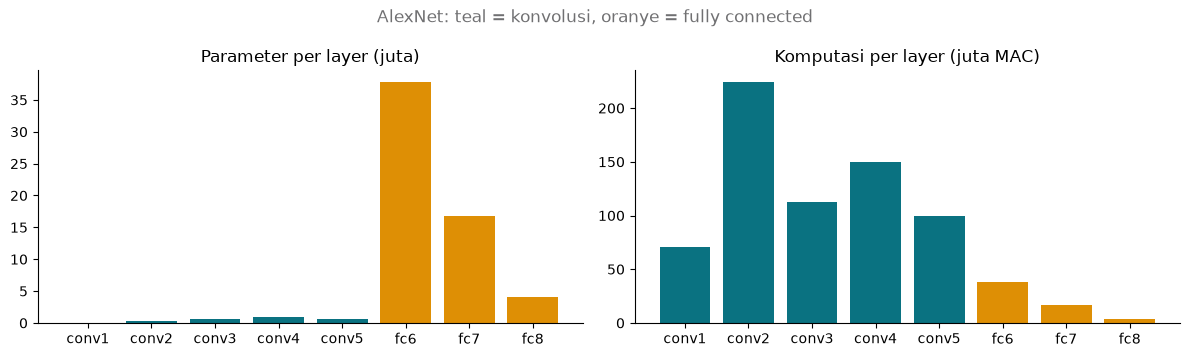

In [5]:
rincian = [r for r in rincian_per_layer(alexnet) if r[1] in ('Conv2d', 'Linear')]
label = [f"{'conv' if t == 'Conv2d' else 'fc'}{i+1}" for i, (_, t, *_x) in enumerate(rincian)]
param = np.array([r[3] for r in rincian]) / 1e6
mac = np.array([r[4] for r in rincian]) / 1e6
warna = [TEAL if r[1] == 'Conv2d' else ORANGE for r in rincian]

is_conv = np.array([r[1] == 'Conv2d' for r in rincian])
print(f"Parameter : conv {param[is_conv].sum():6.2f} jt ({param[is_conv].sum()/param.sum():5.1%}) | FC {param[~is_conv].sum():6.2f} jt ({param[~is_conv].sum()/param.sum():5.1%})")
print(f"MAC       : conv {mac[is_conv].sum():6.1f} jt ({mac[is_conv].sum()/mac.sum():5.1%}) | FC {mac[~is_conv].sum():6.1f} jt ({mac[~is_conv].sum()/mac.sum():5.1%})")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
axs[0].bar(label, param, color=warna)
axs[0].set_title('Parameter per layer (juta)')
axs[1].bar(label, mac, color=warna)
axs[1].set_title('Komputasi per layer (juta MAC)')
for ax in axs:
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle('AlexNet: teal = konvolusi, oranye = fully connected', color=MUTE)
plt.tight_layout()
plt.show()

**Insight penting:** parameter terkonsentrasi di **FC**, sedangkan komputasi terkonsentrasi di **konvolusi**. Inilah sebabnya:
- Arsitektur sesudah AlexNet (GoogLeNet, ResNet) **membuang FC raksasa** dan menggantinya dengan *Global Average Pooling* sehingga ukuran model turun drastis.
- Upaya mempercepat inferensi (MobileNet, Notebook 05) justru menyasar **konvolusi**.

---

## 4. VGG: Mengapa Menumpuk Filter $3\times3$? (Slide 12)

Untuk $C$ kanal masuk dan keluar (tanpa bias):

| Tumpukan | Receptive field | Bobot |
|:--|:--:|:--:|
| $1 \times (5\times5)$ | $5\times5$ | $25C^2$ |
| $2 \times (3\times3)$ | $5\times5$ | $18C^2$ |
| $1 \times (7\times7)$ | $7\times7$ | $49C^2$ |
| $3 \times (3\times3)$ | $7\times7$ | $27C^2$ |

Mari kita buktikan dengan model sungguhan pada $C = 256$.

In [6]:
C = 256

def tumpukan(n_layer, k):
    layers = []
    for _ in range(n_layer):
        layers += [nn.Conv2d(C, C, k, padding=k // 2, bias=False), nn.ReLU()]
    return nn.Sequential(*layers)

print(f"{'Konfigurasi':<16}{'Bobot':>12}{'Rumus':>10}{'Jumlah ReLU':>14}")
for n, k, rumus in [(1, 5, '25C^2'), (2, 3, '18C^2'), (1, 7, '49C^2'), (3, 3, '27C^2')]:
    print(f"{f'{n} x ({k}x{k})':<16}{hitung_param(tumpukan(n, k)):>12,}{rumus:>10}{n:>14}")

print(f"\nPenghematan 2x(3x3) vs 5x5 : {1 - 18/25:.0%}")
print(f"Penghematan 3x(3x3) vs 7x7 : {1 - 27/49:.0%}")

Konfigurasi            Bobot     Rumus   Jumlah ReLU
1 x (5x5)          1,638,400     25C^2             1
2 x (3x3)          1,179,648     18C^2             2


1 x (7x7)          3,211,264     49C^2             1
3 x (3x3)          1,769,472     27C^2             3

Penghematan 2x(3x3) vs 5x5 : 28%
Penghematan 3x(3x3) vs 7x7 : 45%


### 4b. Membuktikan *Receptive Field* Secara Empiris

Bagaimana kita tahu $2\times(3\times3)$ benar-benar "melihat" $5\times5$ piksel? Triknya memakai **gradien**: ambil satu piksel di tengah output, lakukan `backward()`, lalu lihat piksel input mana saja yang gradiennya **tidak nol**. Area itulah *receptive field*-nya.

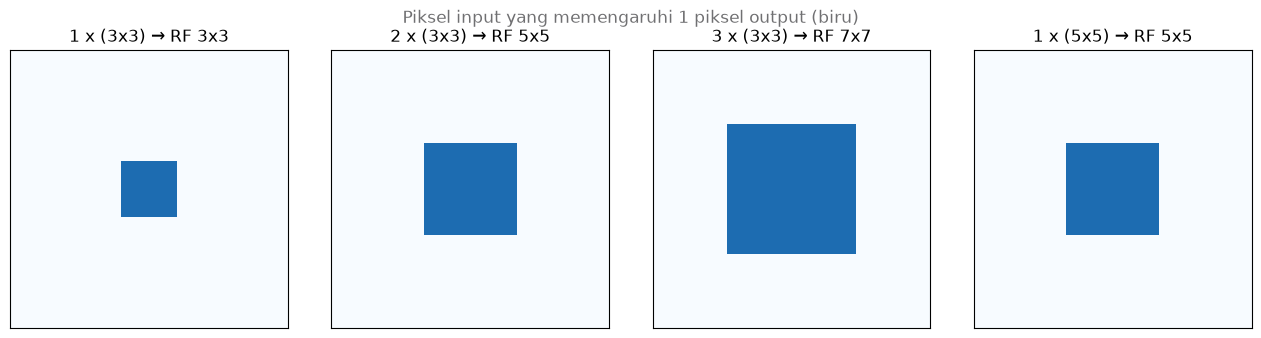

In [7]:
def receptive_field_empiris(n_layer, k=3, ukuran=15):
    net = nn.Sequential(*[nn.Conv2d(1, 1, k, padding=k // 2, bias=False) for _ in range(n_layer)])
    for conv in net:
        nn.init.constant_(conv.weight, 1.0)  # bobot positif agar tidak ada gradien yang saling meniadakan
    x = torch.zeros(1, 1, ukuran, ukuran, requires_grad=True)
    y = net(x)
    y[0, 0, ukuran // 2, ukuran // 2].backward()
    peta = (x.grad[0, 0] != 0).float()
    sisi = int(peta.sum(dim=1).max().item())
    return peta.numpy(), sisi

fig, axs = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (n, k) in zip(axs, [(1, 3), (2, 3), (3, 3), (1, 5)]):
    peta, sisi = receptive_field_empiris(n, k)
    ax.imshow(peta, cmap='Blues', vmin=0, vmax=1.3)
    ax.set_title(f"{n} x ({k}x{k}) → RF {sisi}x{sisi}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Piksel input yang memengaruhi 1 piksel output (biru)', color=MUTE)
plt.tight_layout()
plt.show()

Dua $3\times3$ bertumpuk menghasilkan RF $5\times5$, persis sama dengan satu $5\times5$, tetapi dengan bobot 28% lebih sedikit **dan** dua non-linearitas.

---

## 5. Membangun VGG-16 dari `vgg_block` (Slide 13–15)

Kode `vgg_block` di bawah ini disalin persis dari slide 15. Kita rakit VGG-16 dari konfigurasi `cfg`, lalu cocokkan jumlah parameternya dengan `torchvision.models.vgg16`.

In [8]:
def vgg_block(c_in, c_out, n_conv):
    layers = []
    for i in range(n_conv):
        c = c_in if i == 0 else c_out
        layers += [nn.Conv2d(c, c_out, 3, padding=1),
                   nn.ReLU(inplace=True)]
    layers.append(nn.MaxPool2d(2, 2))       # resolusi / 2
    return nn.Sequential(*layers)

# VGG-16: (jumlah conv, kanal) per blok
cfg = [(2, 64), (2, 128), (3, 256), (3, 512), (3, 512)]


class VGG16(nn.Module):
    def __init__(self, n_kelas=1000):
        super().__init__()
        blok, c_in = [], 3
        for n_conv, c_out in cfg:
            blok.append(vgg_block(c_in, c_out, n_conv))
            c_in = c_out
        self.features = nn.Sequential(*blok)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(0.5),   # FC6
            nn.Linear(4096, 4096), nn.ReLU(inplace=True), nn.Dropout(0.5),          # FC7
            nn.Linear(4096, n_kelas))                                               # FC8

    def forward(self, x):
        return self.classifier(self.features(x))


vgg_kita = VGG16()
vgg_tv = models.vgg16(weights=None)
print(f"VGG-16 buatan kita : {hitung_param(vgg_kita):,} parameter")
print(f"torchvision vgg16  : {hitung_param(vgg_tv):,} parameter")
assert hitung_param(vgg_kita) == hitung_param(vgg_tv)

x = torch.randn(1, 3, 224, 224)
print("\nPerubahan shape per blok:")
for i, blok in enumerate(vgg_kita.features):
    x = blok(x)
    print(f"  Blok {i+1}: {tuple(x.shape[1:])}")

VGG-16 buatan kita : 138,357,544 parameter
torchvision vgg16  : 138,357,544 parameter

Perubahan shape per blok:
  Blok 1: (64, 112, 112)
  Blok 2: (128, 56, 56)
  Blok 3: (256, 28, 28)
  Blok 4: (512, 14, 14)
  Blok 5: (512, 7, 7)


In [9]:
rincian = [r for r in rincian_per_layer(vgg_kita) if r[1] in ('Conv2d', 'Linear')]
param_conv = sum(r[3] for r in rincian if r[1] == 'Conv2d')
param_fc = sum(r[3] for r in rincian if r[1] == 'Linear')
mac_conv = sum(r[4] for r in rincian if r[1] == 'Conv2d')
mac_fc = sum(r[4] for r in rincian if r[1] == 'Linear')
fc6 = [r for r in rincian if r[1] == 'Linear'][0]

print(f"FC6 saja          : {fc6[3]:,} parameter  (7*7*512*4096 + 4096 bias)")
print(f"13 layer konvolusi: {param_conv/1e6:6.1f} jt parameter ({param_conv/(param_conv+param_fc):5.1%}) | {mac_conv/1e9:5.2f} GMAC ({mac_conv/(mac_conv+mac_fc):5.1%})")
print(f"3 layer FC        : {param_fc/1e6:6.1f} jt parameter ({param_fc/(param_conv+param_fc):5.1%}) | {mac_fc/1e9:5.2f} GMAC ({mac_fc/(mac_conv+mac_fc):5.1%})")
print(f"Ukuran file bobot float32: {hitung_param(vgg_kita) * 4 / 1e6:.0f} MB")

FC6 saja          : 102,764,544 parameter  (7*7*512*4096 + 4096 bias)
13 layer konvolusi:   14.7 jt parameter (10.6%) | 15.35 GMAC (99.2%)
3 layer FC        :  123.6 jt parameter (89.4%) |  0.12 GMAC ( 0.8%)
Ukuran file bobot float32: 553 MB


Hasilnya sama dengan slide 14: **FC6 sendiri memuat 102,8 juta bobot**, tetapi **>99% komputasi** ada di konvolusi (15,5 GMAC per citra). VGG-16 besar *dan* lambat, dua masalah yang dijawab oleh GoogLeNet dan ResNet.

---

## 6. GoogLeNet: Konvolusi $1\times1$ sebagai *Bottleneck* (Slide 16–17)

Contoh slide 16: input $28\times28\times192$ diproses 32 filter $5\times5$.
- **Langsung:** $28^2 \cdot 32 \cdot (5\cdot5\cdot192) \approx 120{,}4$ juta MAC.
- **Via $1\times1$ ke 16 kanal dulu:** $28^2\cdot16\cdot192 + 28^2\cdot32\cdot(25\cdot16) \approx 12{,}4$ juta MAC.

In [10]:
langsung = nn.Conv2d(192, 32, 5, padding=2, bias=False)
via_1x1 = nn.Sequential(nn.Conv2d(192, 16, 1, bias=False),
                        nn.Conv2d(16, 32, 5, padding=2, bias=False))

ukuran = (1, 192, 28, 28)
for nama, m in [("Langsung 5x5", langsung), ("1x1 -> 5x5", via_1x1)]:
    print(f"{nama:<14}: {hitung_mac(m, ukuran)/1e6:6.1f} juta MAC, {hitung_param(m):>8,} bobot, output {tuple(m(torch.randn(*ukuran)).shape[1:])}")

Langsung 5x5  :  120.4 juta MAC,  153,600 bobot, output (32, 28, 28)
1x1 -> 5x5    :   12.4 juta MAC,   15,872 bobot, output (32, 28, 28)


Sekarang kita rakit satu **modul Inception** (konfigurasi *inception 3a* pada GoogLeNet). Empat cabang paralel dijalankan pada input yang sama, lalu output-nya **digabung sepanjang dimensi kanal** (`torch.cat(..., dim=1)`).

In [11]:
def conv_relu(c_in, c_out, k):
    return nn.Sequential(nn.Conv2d(c_in, c_out, k, padding=k // 2), nn.ReLU(inplace=True))


class Inception(nn.Module):
    def __init__(self, c_in, c1, c3_red, c3, c5_red, c5, c_pool):
        super().__init__()
        self.b1 = conv_relu(c_in, c1, 1)
        self.b2 = nn.Sequential(conv_relu(c_in, c3_red, 1), conv_relu(c3_red, c3, 3))
        self.b3 = nn.Sequential(conv_relu(c_in, c5_red, 1), conv_relu(c5_red, c5, 5))
        self.b4 = nn.Sequential(nn.MaxPool2d(3, stride=1, padding=1), conv_relu(c_in, c_pool, 1))

    def forward(self, x):
        cabang = [self.b1(x), self.b2(x), self.b3(x), self.b4(x)]
        for i, c in enumerate(cabang):
            print(f"  cabang {i+1}: {tuple(c.shape[1:])}")
        return torch.cat(cabang, dim=1)


inc3a = Inception(192, 64, 96, 128, 16, 32, 32)
out = inc3a(torch.randn(1, 192, 28, 28))
print(f"Output gabungan: {tuple(out.shape[1:])}  (64 + 128 + 32 + 32 = 256 kanal)")
print(f"Parameter modul: {hitung_param(inc3a):,}")

gnet = models.googlenet(weights=None, aux_logits=False, init_weights=False)
print(f"\nGoogLeNet utuh (22 layer): {hitung_param(gnet)/1e6:.1f} juta parameter vs VGG-16 {hitung_param(vgg_tv)/1e6:.1f} juta")

  cabang 1: (64, 28, 28)
  cabang 2: (128, 28, 28)
  cabang 3: (32, 28, 28)
  cabang 4: (32, 28, 28)
Output gabungan: (256, 28, 28)  (64 + 128 + 32 + 32 = 256 kanal)
Parameter modul: 163,696



GoogLeNet utuh (22 layer): 6.6 juta parameter vs VGG-16 138.4 juta


## 7. Recap Batch Normalization (Slide 19)

Untuk setiap kanal, BN menormalkan aktivasi memakai statistik *mini-batch*, lalu menskalakannya kembali dengan parameter yang dilatih $\gamma, \beta$:
$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y = \gamma\hat{x} + \beta$$

Saat `model.eval()`, BN **tidak** lagi memakai statistik batch, melainkan *running mean/var* yang dikumpulkan selama training. Lupa memanggil `model.eval()` adalah salah satu bug paling umum.

In [12]:
torch.manual_seed(0)
x = torch.randn(8, 3, 4, 4) * 5 + 10          # aktivasi dengan mean ~10, std ~5
bn = nn.BatchNorm2d(3)

# Hitung manual: statistik per kanal atas dimensi (batch, tinggi, lebar)
mu = x.mean(dim=(0, 2, 3), keepdim=True)
var = x.var(dim=(0, 2, 3), unbiased=False, keepdim=True)
y_manual = (x - mu) / torch.sqrt(var + bn.eps) * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

bn.train()
y_bn = bn(x)
print(f"Selisih maksimum manual vs nn.BatchNorm2d : {(y_manual - y_bn).abs().max().item():.2e}")
print(f"Mean/std output per kanal (train)          : {y_bn.mean(dim=(0,2,3)).detach().numpy().round(3)} / {y_bn.std(dim=(0,2,3)).detach().numpy().round(3)}")
print(f"Running mean setelah 1 batch (momentum 0.1): {bn.running_mean.numpy().round(3)}")

bn.eval()
y_eval = bn(x)
print(f"Mean output per kanal (eval)               : {y_eval.mean(dim=(0,2,3)).detach().numpy().round(3)}  <- belum ternormalisasi, running stats baru 1 batch")

Selisih maksimum manual vs nn.BatchNorm2d : 4.77e-07
Mean/std output per kanal (train)          : [-0.  0.  0.] / [1.004 1.004 1.004]
Running mean setelah 1 batch (momentum 0.1): [1.021 1.042 1.   ]
Mean output per kanal (eval)               : [4.855 5.307 5.251]  <- belum ternormalisasi, running stats baru 1 batch


## 8. Eksperimen *Degradation Problem*: Plain vs Residual (Slide 20–21)

He et al. (2016) menemukan bahwa menumpuk layer lebih banyak pada jaringan *plain* justru membuat **error latih** naik. Ini bukan *overfitting*, karena error pada data latih pun ikut memburuk.

Kita reproduksi eksperimen versi CIFAR-10 dari makalah ResNet (Bagian 4.2):
- Stem: conv $3\times3$, 16 kanal.
- Tiga *stage* dengan 16 → 32 → 64 kanal (resolusi $32 \to 16 \to 8$), masing-masing $n$ blok berisi 2 conv.
- Kedalaman total $6n + 2$: **$n=3$ → 20 layer**, **$n=9$ → 56 layer**.
- Satu-satunya beda *plain* dan *residual*: ada atau tidaknya penjumlahan `+ shortcut(x)`.

In [13]:
class Blok(nn.Module):
    """Dua conv 3x3 + BN. residual=True menambahkan shortcut (identitas atau proyeksi 1x1)."""
    def __init__(self, c_in, c_out, stride, residual):
        super().__init__()
        self.residual = residual
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.shortcut = nn.Identity()
        if stride != 1 or c_in != c_out:
            self.shortcut = nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride, bias=False), nn.BatchNorm2d(c_out))

    def forward(self, x):
        out = self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))
        if self.residual:
            out = out + self.shortcut(x)      # <-- satu-satunya perbedaan
        return F.relu(out)


class CifarNet(nn.Module):
    def __init__(self, n, residual):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU())
        blok, c_in = [], 16
        for c_out, stride in [(16, 1), (32, 2), (64, 2)]:
            for i in range(n):
                blok.append(Blok(c_in, c_out, stride if i == 0 else 1, residual))
                c_in = c_out
        self.blocks = nn.Sequential(*blok)
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.blocks(self.stem(x))
        return self.fc(F.adaptive_avg_pool2d(x, 1).flatten(1))


KONFIGURASI = {"Plain-20": (3, False), "Plain-56": (9, False), "ResNet-20": (3, True), "ResNet-56": (9, True)}
for nama, (n, res) in KONFIGURASI.items():
    print(f"{nama:<10}: {6*n+2} layer, {hitung_param(CifarNet(n, res)):>8,} parameter")

Plain-20  : 20 layer,  272,474 parameter
Plain-56  : 56 layer,  855,770 parameter
ResNet-20 : 20 layer,  272,474 parameter
ResNet-56 : 56 layer,  855,770 parameter


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

N_TRAIN, N_TEST, EPOCHS = (10_000, 2_000, 5) if MODE_CEPAT else (50_000, 10_000, 15)
train_ds = Subset(train_full, range(N_TRAIN))
test_ds = Subset(test_full, range(N_TEST))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)
print(f"Data latih: {len(train_ds):,} | Data uji: {len(test_ds):,} | Epoch: {EPOCHS}")

Data latih: 10,000 | Data uji: 2,000 | Epoch: 5


### 8a. Diagnosis Sebelum Training: Skala Gradien per Blok

Sebelum melatih, kita lakukan satu *forward-backward* pada model yang baru diinisialisasi, lalu ukur norma gradien bobot `conv1` di setiap blok. Idealnya, skala gradien **relatif seragam** dari blok awal hingga akhir agar semua layer belajar dengan kecepatan serupa.

Plain-56  : blok pertama  293.551 | blok terakhir  0.339 | rasio  865.1x


ResNet-56 : blok pertama    4.741 | blok terakhir  1.051 | rasio    4.5x


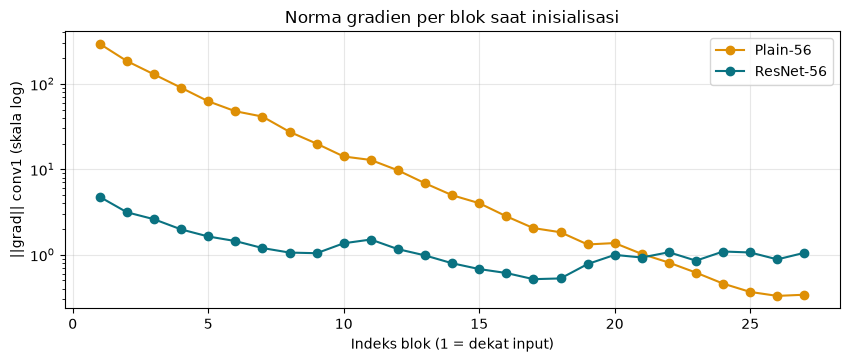

In [15]:
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

plt.figure(figsize=(10, 3.6))
for nama, warna in [("Plain-56", ORANGE), ("ResNet-56", TEAL)]:
    torch.manual_seed(0)
    n, res = KONFIGURASI[nama]
    m = CifarNet(n, res).to(device)
    F.cross_entropy(m(x_batch), y_batch).backward()
    norma = [b.conv1.weight.grad.norm().item() for b in m.blocks]
    plt.semilogy(range(1, len(norma) + 1), norma, 'o-', color=warna, label=nama)
    print(f"{nama:<10}: blok pertama {norma[0]:8.3f} | blok terakhir {norma[-1]:6.3f} | rasio {norma[0]/norma[-1]:6.1f}x")
plt.xlabel('Indeks blok (1 = dekat input)')
plt.ylabel('||grad|| conv1 (skala log)')
plt.title('Norma gradien per blok saat inisialisasi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Apa yang terlihat?** Pada jaringan *plain* 56 layer, skala gradien antar blok **sangat tidak seimbang** (berbeda ratusan kali lipat antara blok awal dan akhir). Pada ResNet-56, jalur *shortcut* menjaga skala gradien tetap dalam orde yang sama.

> Menariknya, dengan BatchNorm gradien di jaringan plain ini **tidak hilang** (*vanishing*). Makalah ResNet sendiri mencatat hal ini: masalahnya adalah **optimisasi yang sulit**, bukan sekadar gradien yang mengecil. Suku $+1$ pada $\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y}\left(1 + \frac{\partial F}{\partial x}\right)$ (slide 21) memberi jalur langsung yang membuat aliran gradien jauh lebih "tertata".

### 8b. Melatih Empat Model

In [16]:
def latih(model, epochs, lr=0.05):
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    riwayat = {'train_loss': [], 'test_acc': []}
    for ep in range(epochs):
        model.train()
        total, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            total += loss.item() * len(y)
            n += len(y)
        riwayat['train_loss'].append(total / n)

        model.eval()
        benar = 0
        with torch.no_grad():
            for x, y in test_loader:
                benar += (model(x.to(device)).argmax(1).cpu() == y).sum().item()
        riwayat['test_acc'].append(benar / len(test_ds))
    return riwayat


hasil = {}
for nama, (n, res) in KONFIGURASI.items():
    torch.manual_seed(0)
    t0 = time.time()
    hasil[nama] = latih(CifarNet(n, res).to(device), EPOCHS)
    print(f"{nama:<10}: train loss akhir {hasil[nama]['train_loss'][-1]:.3f} | "
          f"akurasi uji {hasil[nama]['test_acc'][-1]:.1%} | {time.time()-t0:5.1f} s")

Plain-20  : train loss akhir 1.504 | akurasi uji 40.6% |  16.8 s


Plain-56  : train loss akhir 2.042 | akurasi uji 22.3% |  38.8 s


ResNet-20 : train loss akhir 1.142 | akurasi uji 52.8% |  17.9 s


ResNet-56 : train loss akhir 1.484 | akurasi uji 44.5% |  40.3 s


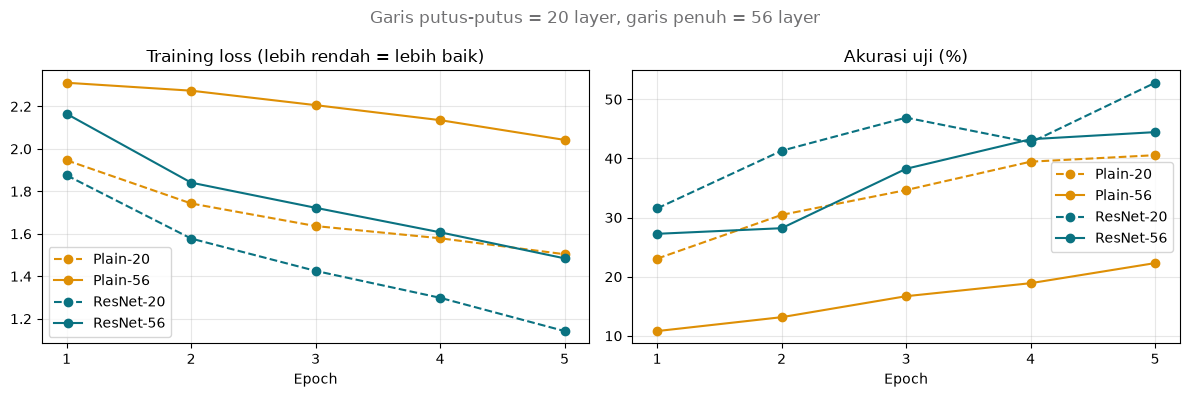

In [17]:
gaya = {"Plain-20": (ORANGE, '--'), "Plain-56": (ORANGE, '-'), "ResNet-20": (TEAL, '--'), "ResNet-56": (TEAL, '-')}
ep = range(1, EPOCHS + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for nama, h in hasil.items():
    warna, ls = gaya[nama]
    axs[0].plot(ep, h['train_loss'], ls, color=warna, marker='o', label=nama)
    axs[1].plot(ep, [a * 100 for a in h['test_acc']], ls, color=warna, marker='o', label=nama)
axs[0].set_title('Training loss (lebih rendah = lebih baik)')
axs[1].set_title('Akurasi uji (%)')
for ax in axs:
    ax.set_xlabel('Epoch')
    ax.set_xticks(list(ep))
    ax.grid(alpha=0.3)
    ax.legend()
plt.suptitle('Garis putus-putus = 20 layer, garis penuh = 56 layer', color=MUTE)
plt.tight_layout()
plt.show()

**Interpretasi (bandingkan dengan slide 20):**
1. **Plain-56 lebih buruk daripada Plain-20**, bahkan pada *training loss*. Menambah 36 layer justru merugikan: inilah *degradation problem*.
2. **ResNet-56 tidak mengalami degradasi separah itu**: dengan jumlah parameter yang sama persis dengan Plain-56, ia belajar jauh lebih cepat.
3. Dalam anggaran epoch yang pendek, ResNet-20 bisa saja masih unggul atas ResNet-56 karena model dalam butuh lebih banyak iterasi. Pada pelatihan penuh (164 epoch), makalah ResNet melaporkan error uji CIFAR-10 **8,75% (ResNet-20) vs 6,97% (ResNet-56)**: yang lebih dalam menang.

---

## 9. Basic Block dan Bottleneck Block (Slide 22–25)

`BasicBlock` di bawah disalin dari slide 23. Uji dari slide: `BasicBlock(64, 128, 2)` harus mengubah $56^2\times64$ menjadi $28^2\times128$ melalui *projection shortcut*.

In [18]:
class BasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        self.shortcut = nn.Identity()
        if stride != 1 or c_in != c_out:   # proyeksi
            self.shortcut = nn.Sequential(
                nn.Conv2d(c_in, c_out, 1, stride, bias=False),
                nn.BatchNorm2d(c_out))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))  # <-- skip


x = torch.randn(1, 64, 56, 56)
blok_id = BasicBlock(64, 64)
blok_proj = BasicBlock(64, 128, 2)
print(f"Identity shortcut  : {tuple(x.shape[1:])} -> {tuple(blok_id(x).shape[1:])}, shortcut = {blok_id.shortcut}")
print(f"Projection shortcut: {tuple(x.shape[1:])} -> {tuple(blok_proj(x).shape[1:])}")

Identity shortcut  : (64, 56, 56) -> (64, 56, 56), shortcut = Identity()
Projection shortcut: (64, 56, 56) -> (128, 28, 28)


In [19]:
def bobot_conv(m):
    """Hanya bobot konvolusi (tanpa BN), sesuai perhitungan slide 24."""
    return sum(mod.weight.numel() for mod in m.modules() if isinstance(mod, nn.Conv2d))

basic_256 = nn.Sequential(nn.Conv2d(256, 256, 3, padding=1, bias=False), nn.Conv2d(256, 256, 3, padding=1, bias=False))
bottleneck_256 = nn.Sequential(nn.Conv2d(256, 64, 1, bias=False),               # reduksi
                               nn.Conv2d(64, 64, 3, padding=1, bias=False),     # 3x3 pada kanal sempit
                               nn.Conv2d(64, 256, 1, bias=False))               # ekspansi
b, bt = bobot_conv(basic_256), bobot_conv(bottleneck_256)
print(f"Basic (2 x 3x3, 256 kanal)   : {b:>10,} bobot")
print(f"Bottleneck (1x1-3x3-1x1)     : {bt:>10,} bobot  -> {b/bt:.1f}x lebih hemat")

print(f"\n{'Model':<10}{'Parameter':>14}{'GMAC':>8}{'Top-1':>9}")
for nama in ['resnet18', 'resnet34', 'resnet50']:
    m = models.get_model(nama, weights=None)
    top1 = models.get_model_weights(nama).IMAGENET1K_V1.meta['_metrics']['ImageNet-1K']['acc@1']
    print(f"{nama:<10}{hitung_param(m):>14,}{hitung_mac(m)/1e9:>8.2f}{top1:>8.2f}%")

Basic (2 x 3x3, 256 kanal)   :  1,179,648 bobot
Bottleneck (1x1-3x3-1x1)     :     69,632 bobot  -> 16.9x lebih hemat

Model          Parameter    GMAC    Top-1


resnet18      11,689,512    1.81   69.76%


resnet34      21,797,672    3.66   73.31%


resnet50      25,557,032    4.09   76.13%


ResNet-50 (bottleneck) hanya sedikit lebih besar daripada ResNet-34 (basic), tetapi akurasinya naik ~3 poin: bottleneck memungkinkan jaringan **lebih dalam dengan biaya yang hampir sama**.

---

## 10. Ringkasan & Tugas Terstruktur (TT 3×60′)

### Ringkasan Eksperimen:
1. **AlexNet & VGG:** ~96% parameter AlexNet dan ~89% parameter VGG-16 ada di FC, tetapi >90% komputasinya ada di konvolusi.
2. **Tumpukan $3\times3$:** *receptive field* sama dengan filter besar (dibuktikan lewat gradien), bobot 28–45% lebih sedikit, dan non-linearitas lebih banyak.
3. **Konvolusi $1\times1$:** mereduksi kanal sebelum filter mahal, sehingga komputasi turun ~10× (120,4 juta → 12,4 juta MAC).
4. **Degradation problem:** Plain-56 kalah dari Plain-20 bahkan pada data latih; menambah *shortcut* dengan parameter yang sama menyelesaikannya.
5. **Bottleneck:** ~17× lebih hemat bobot per blok, kunci ResNet-50/101/152.

---

### Soal Tugas Terstruktur:
1. **Tugas 1 — Verifikasi Latihan Slide:** gunakan `rincian_per_layer` pada `vgg_kita` untuk memeriksa jawaban tangan Anda atas soal *Blok 3 VGG-16* (Latihan Mandiri no. 1 di slide 54).
2. **Tugas 2 — ResNet pada 512 Kanal:** modifikasi sel Bagian 9 untuk 512 kanal (bottleneck 128) dan cocokkan dengan jawaban Latihan Mandiri no. 2.
3. **Tugas 3 — Degradation Lebih Ekstrem:** tambahkan konfigurasi `Plain-110` dan `ResNet-110` ($n=18$). Apakah Plain-110 masih bisa belajar? Catat juga waktu per epoch.
4. **Tugas 4 — Pengaruh BatchNorm:** hapus seluruh `BatchNorm2d` dari `Blok` (ganti dengan `nn.Identity()`), ulangi eksperimen 20 vs 56 layer, dan jelaskan hasilnya dengan grafik norma gradien Bagian 8a.